---
# Задание 2.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [4]:
# Параметры модели
states      = ['E', '5', 'I']
state_idx   = {s: i for i, s in enumerate(states)}
nucleotides = ['A', 'C', 'G', 'T']
nuc_idx     = {n: i for i, n in enumerate(nucleotides)}

# Начальные вероятности
pi = np.array([1.0, 0.0, 0.0])

# Матрица переходов
A = np.array([
    [0.9, 0.1, 0.0],  
    [0.0, 0.0, 1.0],
    [0.0, 0.0, 0.9],
])

# Матрица эмиссий
B = np.array([
    [0.25, 0.25, 0.25, 0.25],
    [0.05, 0.00, 0.95, 0.00],
    [0.40, 0.10, 0.10, 0.40],
])

print("Матрица переходов A:")
print(A)
print("\nМатрица эмиссий B:")
print(B)

Матрица переходов A:
[[0.9 0.1 0. ]
 [0.  0.  1. ]
 [0.  0.  0.9]]

Матрица эмиссий B:
[[0.25 0.25 0.25 0.25]
 [0.05 0.   0.95 0.  ]
 [0.4  0.1  0.1  0.4 ]]


## Реализация алгоритмов в log-space

In [5]:
NEG_INF = -np.inf

def log(x):
    """Безопасный логарифм"""
    with np.errstate(divide='ignore'):
        return np.log(x)

def log_sum_exp(log_probs):
    """Устойчивый log-sum-exp для сложения вероятностей в log-space."""
    max_lp = np.max(log_probs)
    if max_lp == NEG_INF:
        return NEG_INF
    return max_lp + np.log(np.sum(np.exp(log_probs - max_lp)))


# Функция перевода последовательности в индексы
def encode(seq):
    return [nuc_idx[c] for c in seq]


def viterbi(obs):
    """
    Алгоритм Витерби в log-space.
    obs : list[int] — последовательность индексов нуклеотидов.
    Возвращает:
        best_path  : list[str]  оптимальный путь состояний.
        log_prob   : float      log-вероятность оптимального пути.
    """
    T  = len(obs)
    N  = len(states)
    log_A = log(A)
    log_B = log(B)
    log_pi = log(pi)

    delta   = np.full((T, N), NEG_INF)
    psi     = np.zeros((T, N), dtype=int) # argmax предыдущего состояния

    # Инициализация
    delta[0] = log_pi + log_B[:, obs[0]]

    # Рекуррентный шаг
    for t in range(1, T):
        for s in range(N):
            trans_scores = delta[t-1] + log_A[:, s]
            best_prev    = np.argmax(trans_scores)
            delta[t, s]  = trans_scores[best_prev] + log_B[s, obs[t]]
            psi[t, s]    = best_prev

    # Обратный ход
    best_last = np.argmax(delta[T-1])
    log_prob  = delta[T-1, best_last]

    path = [0] * T
    path[T-1] = best_last
    for t in range(T-2, -1, -1):
        path[t] = psi[t+1, path[t+1]]

    best_path = [states[s] for s in path]
    return best_path, log_prob



def forward(obs):
    """
    Алгоритм Forward в log-space.
    Возвращает:
        log_alpha : ndarray (T, N)
        log_prob  : float
    """
    T  = len(obs)
    N  = len(states)
    log_A  = log(A)
    log_B  = log(B)
    log_pi = log(pi)

    log_alpha = np.full((T, N), NEG_INF)
    log_alpha[0] = log_pi + log_B[:, obs[0]]

    for t in range(1, T):
        for s in range(N):
            log_alpha[t, s] = log_sum_exp(log_alpha[t-1] + log_A[:, s]) + log_B[s, obs[t]]

    log_prob = log_sum_exp(log_alpha[T-1])
    return log_alpha, log_prob


def backward(obs):
    """
    Алгоритм Backward в log-space.
    Возвращает:
        log_beta : ndarray (T, N)  log backward-переменные.
    """
    T = len(obs)
    N = len(states)
    log_A = log(A)
    log_B = log(B)

    log_beta = np.full((T, N), NEG_INF)
    log_beta[T-1] = 0.0   # log(1) = 0

    for t in range(T-2, -1, -1):
        for s in range(N):
            log_beta[t, s] = log_sum_exp(
                log_A[s, :] + log_B[:, obs[t+1]] + log_beta[t+1]
            )

    return log_beta


def posterior(obs):
    """
    Апостериорное декодирование.
    Возвращает:
        gamma : ndarray (T, N)  γ_t(s).
    """
    log_alpha, log_prob = forward(obs)
    log_beta = backward(obs)

    log_gamma = log_alpha + log_beta - log_prob
    gamma = np.exp(log_gamma)
    return gamma



---
## 2.1 Алгоритм Витерби для последовательности из статьи Eddy

In [7]:
# Последовательность из статьи
seq_str = "CTTCATGTGAAAGCAGACGTAAGTCA"
obs = encode(seq_str)

path, log_p = viterbi(obs)
path_str = ''.join(path)

print(f"Входная последовательность : {seq_str}")
print(f"Путь Витерби               : {path_str}")
print(f"Log-вероятность пути       : {log_p:.6f}")
print(f"Вероятность пути           : {np.exp(log_p):.3e}")

# Путь из статьи Eddy
eddy_path = "EEEEEEEEEEEEEEEEEE5IIIIIII"

print(f"Путь из статьи Eddy (2004) : {eddy_path}")

Входная последовательность : CTTCATGTGAAAGCAGACGTAAGTCA
Путь Витерби               : EEEEEEEEEEEEEEEEEEEEEEEEEE
Log-вероятность пути       : -38.677666
Вероятность пути           : 1.594e-17
Путь из статьи Eddy (2004) : EEEEEEEEEEEEEEEEEE5IIIIIII


Заметим, пути не совпадают.

---
## 2.2 Алгоритм Forward — полная вероятность последовательности

In [8]:
log_alpha, log_prob = forward(obs)

print(f"Последовательность : {seq_str}")
print(f"log P       = {log_prob:.6f}")
print(f"P           = {np.exp(log_prob):.6e}")

Последовательность : CTTCATGTGAAAGCAGACGTAAGTCA
log P       = -37.674845
P           = 4.345329e-17


---
## 2.3 Апостериорное декодирование

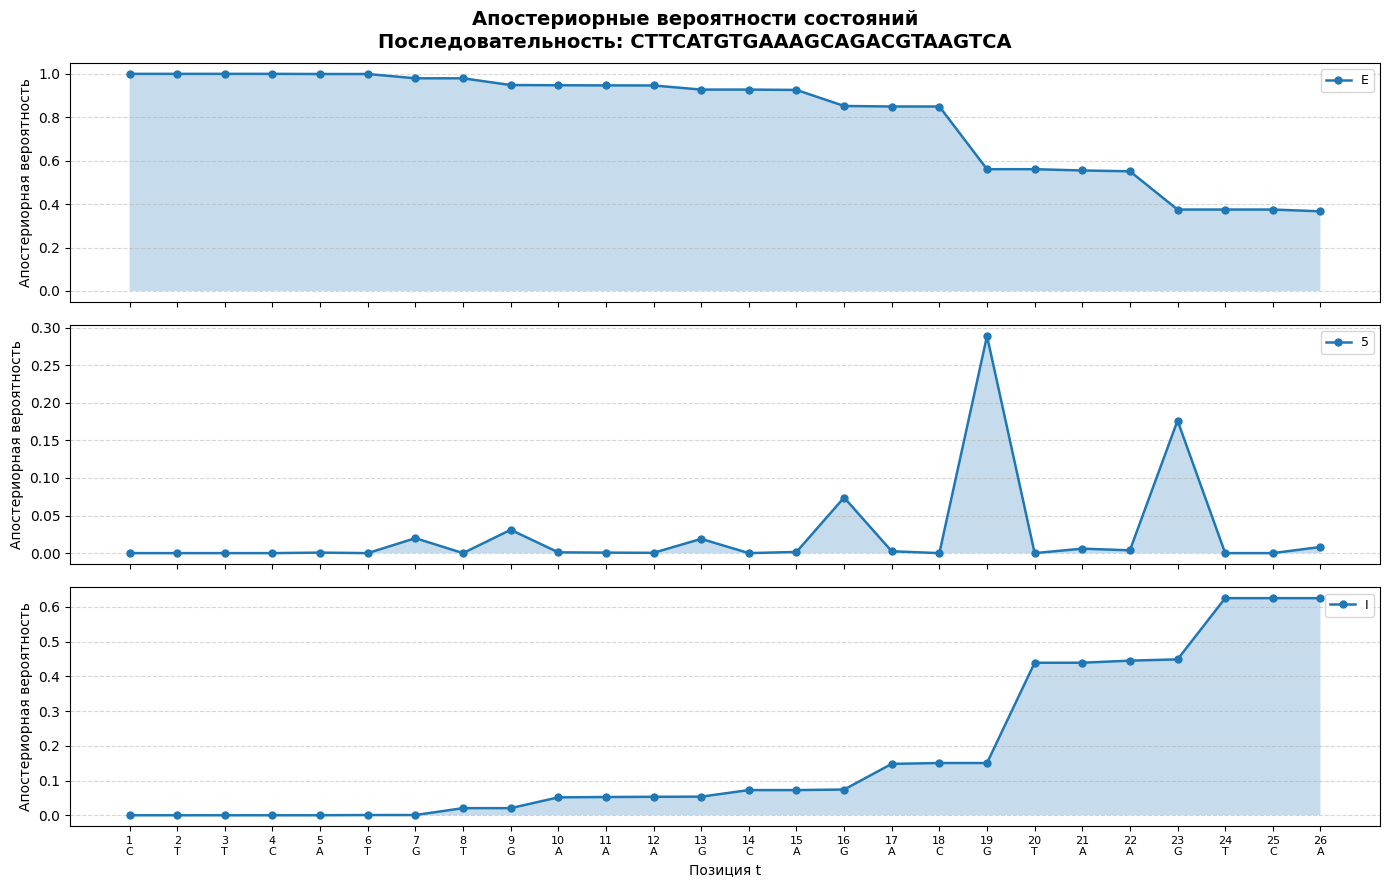

In [10]:
gamma = posterior(obs)
T_len = len(seq_str)
t_axis = np.arange(1, T_len + 1)
state_names = ['E', '5', 'I']

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle(
    f'Апостериорные вероятности состояний\nПоследовательность: {seq_str}',
    fontsize=14, fontweight='bold'
)

for idx, (ax, name) in enumerate(zip(axes, state_names)):
    probs = gamma[:, idx]

    ax.fill_between(t_axis, probs, alpha=0.25)
    ax.plot(t_axis, probs, '-o', markersize=5, linewidth=1.8, label=name)


    ax.set_ylabel(f'Апостериорная вероятность', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.legend(loc='upper right', fontsize=9)

    if idx == 2:
        ax.set_xticks(t_axis)
        labels = [f'{t}\n{c}' for t, c in zip(t_axis, seq_str)]
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_xlabel('Позиция t', fontsize=10)

plt.tight_layout()
plt.show()

Из графика (и из списка ниже) видно что ***максимумы апостериорных вероятностей:***  
 **Экзон** t=1, 2, 3, 4 (нуклеотиды C, T, T, C)  
 **Сайт сплайсинга** t=19 (нуклеотид G)  
 **Интрон** t=24, 25, 26 (нуклеотиды T, C, A)


In [12]:
indices = list(range(0, T_len))
for t in indices:
    print(f"{t+1:>4} {seq_str[t]:>10} {gamma[t,0]:>8.4f} {gamma[t,1]:>8.4f} {gamma[t,2]:>8.4f}")

   1          C   1.0000   0.0000   0.0000
   2          T   1.0000   0.0000   0.0000
   3          T   1.0000   0.0000   0.0000
   4          C   1.0000   0.0000   0.0000
   5          A   0.9993   0.0007   0.0000
   6          T   0.9993   0.0000   0.0007
   7          G   0.9795   0.0198   0.0007
   8          T   0.9795   0.0000   0.0205
   9          G   0.9485   0.0310   0.0205
  10          A   0.9475   0.0010   0.0515
  11          A   0.9468   0.0006   0.0525
  12          A   0.9464   0.0004   0.0532
  13          G   0.9275   0.0189   0.0536
  14          C   0.9275   0.0000   0.0725
  15          A   0.9260   0.0016   0.0725
  16          G   0.8520   0.0739   0.0740
  17          A   0.8496   0.0024   0.1480
  18          C   0.8496   0.0000   0.1504
  19          G   0.5609   0.2887   0.1504
  20          T   0.5609   0.0000   0.4391
  21          A   0.5549   0.0059   0.4391
  22          A   0.5512   0.0037   0.4451
  23          G   0.3750   0.1762   0.4488
  24       